## Putting it all together for Training
Pipeline: Preprocessing -> Feature extraction -> spike encoding ->training

In [1]:
from pipeline_functions import *

import numpy as np

import snntorch.spikeplot as splt
import snntorch as snn
from snntorch import functional as SF

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

#sets seed for random to 42
torch.manual_seed(42) 

# sets device for tensors and model
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


### Preprocessing

In [2]:
## preprocessing function to be inputted

preproc_ds, y = fn_preprocess.preprocess_training("C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s17_v72.mat")

150
750


(32, 307, 900)
(900,)


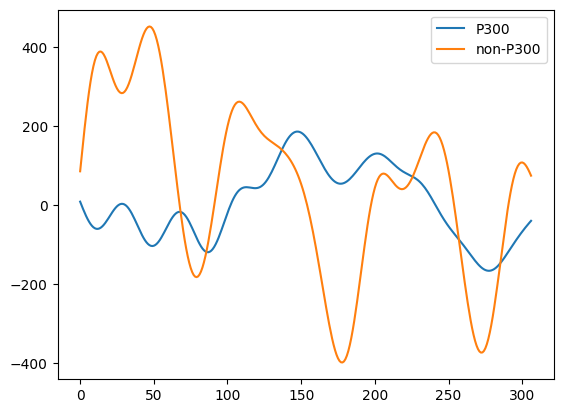

In [3]:
print(preproc_ds.shape)
print(y.shape)
avg_P300 = preproc_ds[12, :, :150].sum(axis=1)
avg_non_P300 = preproc_ds[12, :, 150:].sum(axis=1)
plt.plot(avg_P300, label='P300')
plt.plot(avg_non_P300, label='non-P300')
plt.legend()


### Feature Extraction

In [4]:
## feature extraction
X_norm, fe_X = fn_feature_extraction.extractFeatures(preproc_ds)

X shape: (900, 32, 307)
Shape after normalization: (900, 32, 307)
Features array shape: (900, 160)
Reshaped tensor for SNN input: (900, 9824)


In [ ]:
# only pz electrode, uncomment to change to only have that electrode, will also have to change initial layer in module creation
# X_norm = X_norm[:, 12, :]
# print(X_norm.shape)

(900, 307)


### Spike Encoding

This is a first place we can alter hyperparameters for results <br>
We can change:
- T_ms
- dt_ms
- r_min
- r_max

In [7]:
T_ms = 100
dt_ms = 1
r_min = 150
r_max = 300
encoded_X, r_hz = spike_encoding.deterministic_rate(X_norm, T_ms=T_ms, dt_ms=dt_ms, r_min=r_min, r_max=r_max)
print(encoded_X.shape)
print(r_hz.shape)

(900, 307, 100)
(900, 307)


In [8]:
print(encoded_X[1, 1, :])
print(r_hz[1, 1])
print(encoded_X.mean())

[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0
 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1]
211.34674
0.21764411871154543


### Create tensors and dataloaders from the data

Hyperparameter to tune
- batch_size

In [9]:
batch_size = 128

# in order (trials, time_steps, features) by swapping last two dimensions
encoded_X = np.moveaxis(encoded_X, source=-1, destination=1)
print(encoded_X.shape)

train_loader, val_loader, test_loader, class_weights = train.prepare_training_data(encoded_X, y, batch_size=batch_size)

(900, 100, 307)
Train size: 630, Val size: 135, Test size: 135
Training Class Counts:  tensor([519, 111])
Training Class Weights: tensor([0.3524, 1.6476])


### Module Creation

Hyperparameters:
- hidden_layer
- betas for each LIF layer
- thresholds for each LIF layer (**important!!)

In [10]:
# determined from feature extraction
num_features = encoded_X.shape[2] # * encoded_X.shape[3]
print(num_features)

#tunable
hidden_layer = 128
betas = [0.9, 0.9]
thresholds = [1, 2.1]

snn = SNNModule.createSNN(num_features, hidden_layer=hidden_layer, betas=betas, thresholds=thresholds)

307


### Training Hyperparameters

Tunable:
- num_epochs (for hyperparameter tuning, keep low to find other parameters optimal, then increase once found for real training)
- lr (learning rate: How fast the model changes)
- criterion: loss function to use, changed to Cross Entropy loss to calculate for membrane potential instead of spikes (hopefully more stable)
- optimizer: method to change weights, can use Adam, SGD w/ momentum, and others. Adam is usually the best but others can be checked
- weight_decay and more: there are other parameters we can change if these dont give good results

In [11]:
num_epochs = 25
lr = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(snn.parameters(), lr=lr)

update_every = 1 # will not change results, just prints updates divisible by this number

history = train.train(model=snn, num_epochs=num_epochs, train_loader=train_loader, val_loader=val_loader,
                      criterion=criterion, optimizer=optimizer, device=device, update_every=update_every, batch_first=True)

Avg output spike rate: 0.3385
Avg output membrane max: 3.0892
Epoch 1: Training Loss: 0.7030, Training Accuracy: 50.79%, Validation Loss: 0.7945, Validation Accuracy: 13.33%
Avg output spike rate: 0.3308
Avg output membrane max: 3.1574
Epoch 2: Training Loss: 0.6975, Training Accuracy: 50.32%, Validation Loss: 0.7190, Validation Accuracy: 85.19%
Avg output spike rate: 0.3211
Avg output membrane max: 3.2251
Epoch 3: Training Loss: 0.6975, Training Accuracy: 51.90%, Validation Loss: 0.6048, Validation Accuracy: 86.67%
Avg output spike rate: 0.2954
Avg output membrane max: 3.0427
Epoch 4: Training Loss: 0.6965, Training Accuracy: 49.84%, Validation Loss: 0.7545, Validation Accuracy: 22.22%
Avg output spike rate: 0.2806
Avg output membrane max: 3.0358
Epoch 5: Training Loss: 0.7003, Training Accuracy: 48.57%, Validation Loss: 0.6859, Validation Accuracy: 20.00%
Avg output spike rate: 0.2710
Avg output membrane max: 3.0851
Epoch 6: Training Loss: 0.6949, Training Accuracy: 52.38%, Validatio

In [16]:
data, targets = next(iter(val_loader))
print(data.shape)
data, targets = data.to(device), targets.to(device)
with torch.no_grad():
    snn.eval()
    spk_rec, mem_rec = snn(data, batch_first=True)

spk_rec = spk_rec[:, 4, :]
mem_rec = mem_rec[:, 4, :]
#print(mem_rec)
print(spk_rec)
#print(mem_rec.shape)
print("Shape of output:", spk_rec.shape)
print("Sum of spikes for each output:", spk_rec.sum(axis=0))

torch.Size([128, 100, 307])
tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 1.],
        [1., 0.],
        [0., 0.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [1., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 1.],
        [1., 0.],
        [0., 0.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [1., 0.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [1., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [1., 0.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],


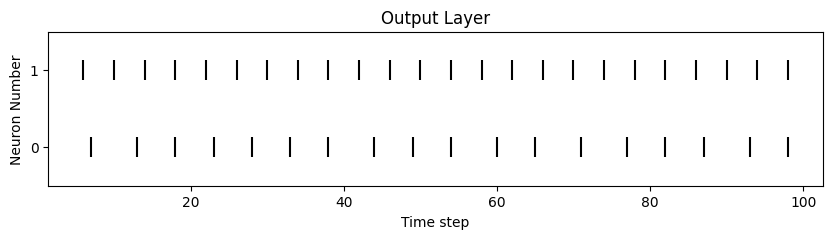

In [17]:
fig = plt.figure(facecolor="w", figsize=(10, 2))
ax = fig.add_subplot(111)

#  s: size of scatter points; c: color of scatter points
splt.raster(spk_rec, ax, s=200, c="black", marker='|')
plt.yticks([0, 1], ['0', '1'])
ax.set_ylim(-0.5, 1.5)
plt.title("Output Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

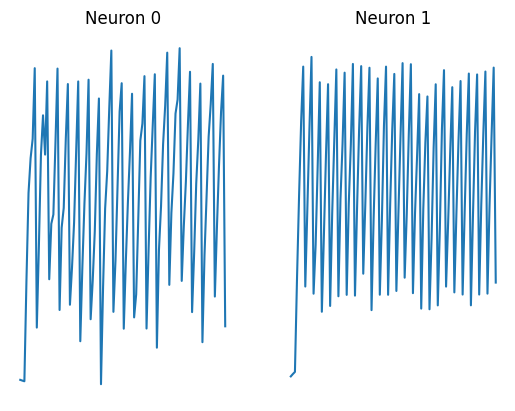

In [14]:
splt.traces(mem_rec, dim=(1, 2), titles=['Neuron 0', 'Neuron 1'])

### Final Decision

Here we can save our weight parameters to be loaded in

In [15]:
model_weights = snn.state_dict()

weights_file_path = 'model_weights/snn_weights.pth'

torch.save(model_weights, weights_file_path)